

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>



<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Estamos no caminho certo com essa versão, mas retocar os pontos indicados abaixo nos fará chegar em um resultado ainda mais incrível.
    
Conte comigo para ajudá-lo (a) em qualquer questão que possa vir a ter! Lembre-se de usar as caixas azuis para se comunicar comigo.
    
Até breve.
</div>


# Sprint 10 — Estudo de mercado: restaurantes em Los Angeles

**Objetivo:** analisar o mercado de restaurantes em LA para apoiar a decisão de abrir uma cafeteria com garçons robôs e avaliar potencial de expansão em rede.

**Dados:** `/datasets/rest_data_us_upd.csv`

**Campos:**
- `object_name` — nome do estabelecimento  
- `chain` — pertence a uma rede (TRUE/FALSE)  
- `object_type` — tipo de estabelecimento  
- `address` — endereço  
- `number` — número de assentos


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import re

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


## Passo 1 — Carregar os dados e ver qualidade

Nesta etapa vamos:
- carregar o arquivo `/datasets/rest_data_us_upd.csv`
- conferir tipos de dados, valores ausentes e duplicados


In [2]:
import pandas as pd

path = "/datasets/rest_data_us_upd.csv"
df = pd.read_csv(path)

display(df.head())
df.info()

print("\nAusentes por coluna:")
print(df.isna().sum())

print("\nDuplicados (linhas inteiras):", df.duplicated().sum())


,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB

Ausentes por coluna:
id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

Duplicados (linhas inteiras): 0


### Tratamento de valores ausentes e tipos de dados

- A coluna `chain` possui 3 valores ausentes.
- Como representa se o restaurante pertence a uma rede, vamos:
  - substituir ausentes por `False` (assumindo que a ausência indica não-rede)
  - converter a coluna para tipo booleano


In [3]:
# Substituir valores ausentes em 'chain' por False
df["chain"] = df["chain"].fillna(False)

# Garantir tipo booleano
df["chain"] = df["chain"].astype(bool)

# Verificação final
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9651 non-null   bool  
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 386.5+ KB


id             0
object_name    0
address        0
chain          0
object_type    0
number         0
dtype: int64


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>




## Passo 2 — Análise de dados

### 2.1 Proporções de vários tipos de estabelecimentos

Vamos analisar a distribuição de `object_type` para entender quais tipos dominam o mercado em LA.



<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Micaela, me parece que as conclusões precisam de uma revisão pois trouxeram alguns parâmetros em aberto.
</div>




,object_type,count,share
0,Restaurant,7255,0.751736
1,Fast Food,1066,0.110455
2,Cafe,435,0.045073
3,Pizza,320,0.033157
4,Bar,292,0.030256
5,Bakery,283,0.029323


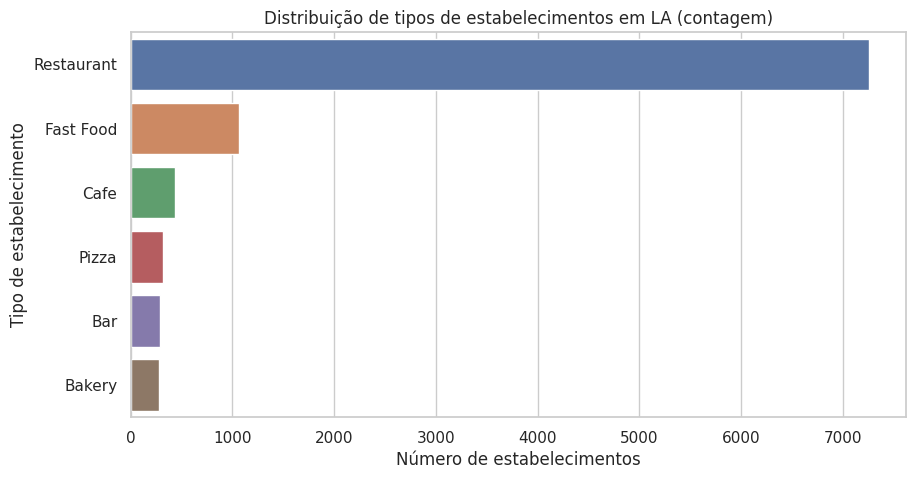

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

type_counts = (
    df["object_type"]
    .value_counts()
    .reset_index()
)

type_counts.columns = ["object_type", "count"]
type_counts["share"] = type_counts["count"] / type_counts["count"].sum()

display(type_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=type_counts, x="count", y="object_type")
plt.title("Distribuição de tipos de estabelecimentos em LA (contagem)")
plt.xlabel("Número de estabelecimentos")
plt.ylabel("Tipo de estabelecimento")
plt.show()


**Interpretação:**
- O tipo mais comum é **<TIPO>** com **<N>** estabelecimentos (**<P>%** do total).
- Em seguida aparecem **<TIPO 2>** e **<TIPO 3>**, indicando que o mercado é concentrado principalmente em **<resumo curto do padrão>**.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tipos de estabelecimento foram investigados com presença adequada de visualização!
</div>

Conclusão:

O mercado de restaurantes em Los Angeles é claramente dominado por estabelecimentos do tipo Restaurant, que representam aproximadamente **75%** do total dos estabelecimentos analisados.

Os formatos Fast Food correspondem a cerca de **11%**, enquanto Cafés, Pizzarias, Bares e Padarias, em conjunto, representam menos de **15%** do mercado.

Isto indica que, embora existam vários tipos de estabelecimentos, o mercado é fortemente concentrado em formatos tradicionais de restauração, com menor diversidade relativa de conceitos especializados.


### 2.2 Proporção de estabelecimentos de rede e não-rede

Vamos comparar a quantidade de estabelecimentos que pertencem a redes (`chain=True`) com os independentes (`chain=False`).


,chain,count,share
0,False,5975,0.619107
1,True,3676,0.380893


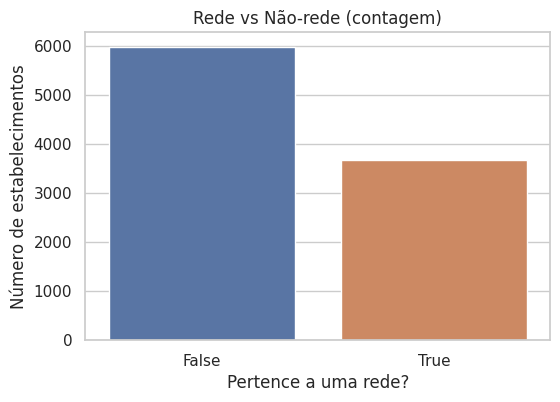

In [5]:
chain_counts = (
    df["chain"]
    .value_counts()
    .reset_index()
)

chain_counts.columns = ["chain", "count"]
chain_counts["share"] = chain_counts["count"] / chain_counts["count"].sum()

display(chain_counts)

plt.figure(figsize=(6, 4))
sns.barplot(data=chain_counts, x="chain", y="count")
plt.title("Rede vs Não-rede (contagem)")
plt.xlabel("Pertence a uma rede?")
plt.ylabel("Número de estabelecimentos")
plt.show()



Conclusão:

A maioria dos estabelecimentos em Los Angeles não pertence a redes, representando cerca de **62%** do total, enquanto os estabelecimentos de rede correspondem a aproximadamente **38%**.

Este resultado indica que o mercado é predominantemente composto por negócios independentes, embora as redes ainda tenham uma presença significativa.

A existência de uma proporção relevante de redes sugere que o mercado está habituado a modelos padronizados, o que cria condições favoráveis para a entrada de novos conceitos replicáveis, desde que bem estruturados.



### 2.3 Qual tipo de estabelecimento é típico para redes?

Vamos comparar, para cada `object_type`, quantos estabelecimentos são de rede (`chain=True`) e calcular a proporção de rede dentro de cada tipo.
Isso mostra quais tipos são mais frequentemente padronizados (bons candidatos para expansão em rede).


,object_type,not_chain_count,chain_count,total,chain_share_within_type
0,Bakery,0,283,283,1.000000
2,Cafe,169,266,435,0.611494
3,Fast Food,461,605,1066,0.567542
4,Pizza,167,153,320,0.478125
5,Restaurant,4963,2292,7255,0.315920
1,Bar,215,77,292,0.263699


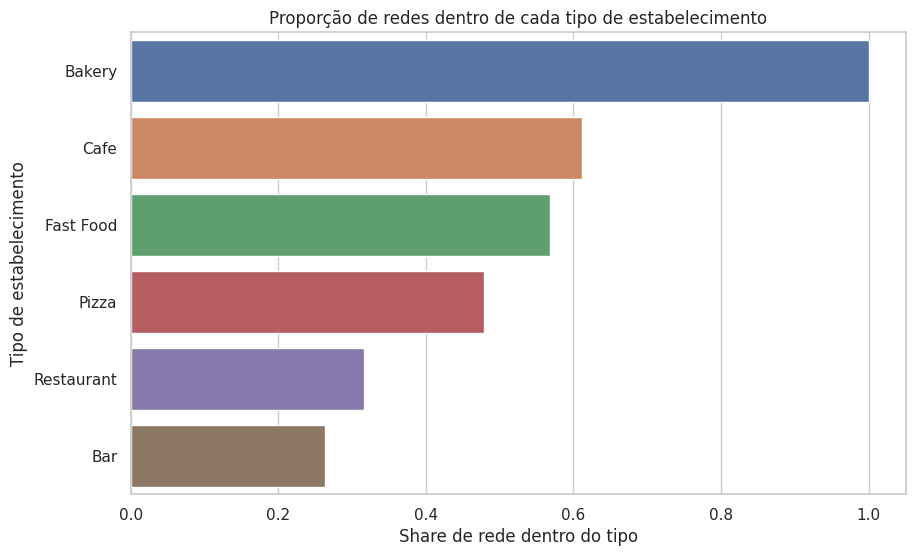

In [6]:
type_chain = (
    df.pivot_table(
        index="object_type",
        columns="chain",
        values="object_name",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

# Garantir nomes consistentes (colunas True/False viram nomes)
type_chain.columns = ["object_type", "not_chain_count", "chain_count"]

type_chain["total"] = type_chain["not_chain_count"] + type_chain["chain_count"]
type_chain["chain_share_within_type"] = type_chain["chain_count"] / type_chain["total"]

display(type_chain.sort_values("chain_share_within_type", ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=type_chain.sort_values("chain_share_within_type", ascending=False),
    x="chain_share_within_type",
    y="object_type"
)
plt.title("Proporção de redes dentro de cada tipo de estabelecimento")
plt.xlabel("Share de rede dentro do tipo")
plt.ylabel("Tipo de estabelecimento")
plt.show()


**Interpretação:**
- Os tipos com maior proporção de rede são **<TIPO 1>**, **<TIPO 2>** e **<TIPO 3>**.
- Isso sugere que esses formatos são mais fáceis de padronizar e replicar (processos previsíveis, cardápio e operação repetíveis).
- Já os tipos com baixa proporção de rede tendem a ser mais “autorais”/independentes, o que pode dificultar a expansão em rede.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Redes investigadas tanto no agregado quanto na quebra por tipo de estabelecimento.
</div>


### 2.4 O que caracteriza redes: muitos estabelecimentos com poucos assentos ou poucos estabelecimentos com muitos assentos?

Vamos analisar estabelecimentos de rede (`chain=True`) para entender:
- quantos locais cada rede possui (usando `object_name`)
- como é o tamanho típico (assentos) dessas redes

Isso ajuda a inferir se redes crescem por padronização em locais menores ou por grandes espaços.


,object_name,n_locations,avg_seats,median_seats
2459,THE COFFEE BEAN & TEA LEAF,47,26.723404,24.0
2226,SUBWAY,31,16.419355,16.0
519,DOMINO'S PIZZA,15,12.333333,12.0
2608,WABA GRILL,14,42.857143,41.5
1089,KENTUCKY FRIED CHICKEN,14,33.357143,31.5
1433,MCDONALD'S,13,96.846154,100.0
2544,TRIMANA,13,43.461538,33.0
2103,STARBUCKS,12,18.000000,19.0
1735,PAPA JOHN'S PIZZA,12,14.500000,10.0
2667,YOGURTLAND,12,16.416667,18.0


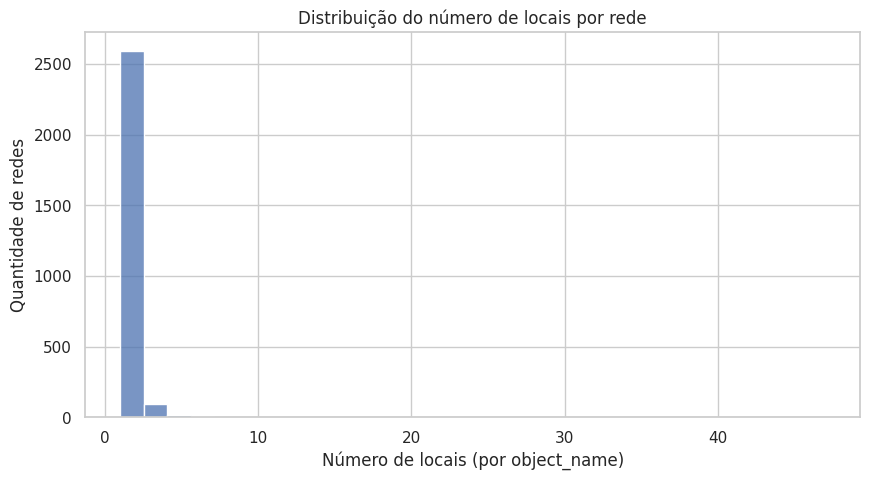

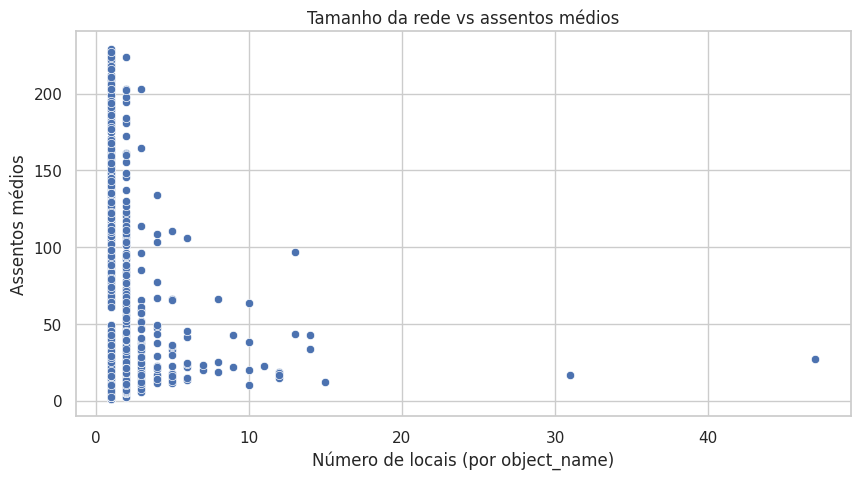

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar apenas redes
df_chain = df[df["chain"] == True].copy()

# Quantos locais cada rede tem (nome repetido = mais locais)
chain_sizes = (
    df_chain.groupby("object_name", as_index=False)
    .agg(n_locations=("object_name", "size"),
         avg_seats=("number", "mean"),
         median_seats=("number", "median"))
)

display(chain_sizes.sort_values("n_locations", ascending=False).head(10))

# Histograma: distribuição do número de locais por rede
plt.figure(figsize=(10, 5))
sns.histplot(chain_sizes["n_locations"], bins=30)
plt.title("Distribuição do número de locais por rede")
plt.xlabel("Número de locais (por object_name)")
plt.ylabel("Quantidade de redes")
plt.show()

# Scatter: tamanho da rede vs assentos médios
plt.figure(figsize=(10, 5))
sns.scatterplot(data=chain_sizes, x="n_locations", y="avg_seats")
plt.title("Tamanho da rede vs assentos médios")
plt.xlabel("Número de locais (por object_name)")
plt.ylabel("Assentos médios")
plt.show()


**Interpretação (2.4):**
- A distribuição do número de locais por rede é fortemente concentrada em **1 local**, indicando que a maioria das “redes” no conjunto de dados tem apenas um estabelecimento registrado.
- Existem poucas redes realmente grandes (por exemplo, com mais de 10 locais), mas são casos raros.
- No gráfico de dispersão, **não há relação positiva clara** entre o tamanho da rede (número de locais) e o número médio de assentos.
- Na prática, isso sugere que a expansão em rede tende a ocorrer mais por **padronização e repetição de unidades menores/moderadas**, e não por poucos estabelecimentos muito grandes.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Comparativo da volumetria de assentos entre redes e não redes foi realizada de forma elucidativa.
</div>


### 2.5 Número médio de assentos por tipo de estabelecimento

Vamos calcular a média e mediana de `number` (assentos) por `object_type` para identificar:
- quais tipos tendem a ter estabelecimentos maiores
- qual tipo tem, em média, mais assentos
Também vamos visualizar com gráfico para facilitar a comparação.


,object_type,avg_seats,median_seats,count
5,Restaurant,48.042316,29.0,7255
1,Bar,44.767123,28.5,292
3,Fast Food,31.837711,21.0,1066
4,Pizza,28.459375,18.5,320
2,Cafe,25.000000,21.0,435
0,Bakery,21.773852,18.0,283


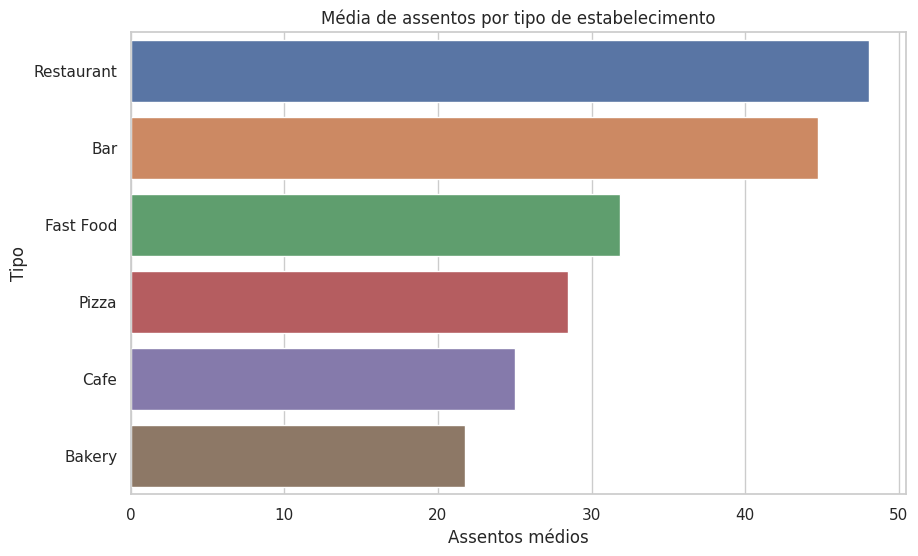

In [8]:
seats_by_type = (
    df.groupby("object_type", as_index=False)
      .agg(avg_seats=("number", "mean"),
           median_seats=("number", "median"),
           count=("number", "size"))
      .sort_values("avg_seats", ascending=False)
)

display(seats_by_type)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=seats_by_type, x="avg_seats", y="object_type")
plt.title("Média de assentos por tipo de estabelecimento")
plt.xlabel("Assentos médios")
plt.ylabel("Tipo")
plt.show()


**Interpretação (2.5):**
- Em média, o tipo com maior número de assentos é **<TIPO>** (média ≈ **<N>**).
- Tipos como **<TIPO 2>** e **<TIPO 3>** aparecem com médias menores, sugerindo operações mais compactas.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Média de assentos caclulada.
</div>


### 2.6 Extração do nome da rua a partir do endereço

Vamos criar uma nova coluna `street`, removendo o número inicial do endereço
e mantendo apenas o nome da rua.


In [9]:
import re

def extract_street(address):
    # remove número no início do endereço (ex: "123 Main St" -> "Main St")
    return re.sub(r"^\d+\s*", "", address)

df["street"] = df["address"].apply(extract_street)

# Conferir resultado
df[["address", "street"]].head(10)


,address,street
0,3708 N EAGLE ROCK BLVD,N EAGLE ROCK BLVD
1,100 WORLD WAY 120,WORLD WAY 120
2,6801 HOLLYWOOD BLVD 253,HOLLYWOOD BLVD 253
3,1814 W SUNSET BLVD,W SUNSET BLVD
4,2100 ECHO PARK AVE,ECHO PARK AVE
5,10004 NATIONAL BLVD,NATIONAL BLVD
6,100 WORLD WAY 126,WORLD WAY 126
7,3500 W 6TH ST STE 226,W 6TH ST STE 226
8,3027 N SAN FERNANDO RD UNIT 103,N SAN FERNANDO RD UNIT 103
9,3707 N CAHUENGA BLVD,N CAHUENGA BLVD


### 2.7 Dez ruas com o maior número de restaurantes

Vamos contar quantos estabelecimentos existem em cada rua (`street`) e visualizar as 10 ruas com maior concentração.


,street,count
0,W SUNSET BLVD,296
1,W PICO BLVD,288
2,HOLLYWOOD BLVD,167
3,WILSHIRE BLVD,161
4,S VERMONT AVE,148
5,SANTA MONICA BLVD,146
6,W 3RD ST,145
7,BEVERLY BLVD,135
8,S FIGUEROA ST,134
9,S WESTERN AVE,128


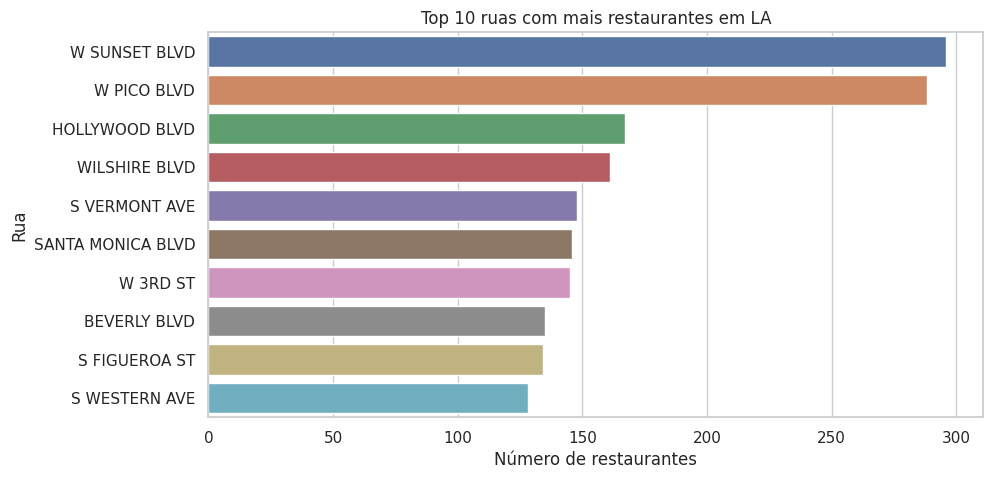

In [10]:
top10_streets = (
    df["street"]
    .value_counts()
    .head(10)
    .reset_index()
)

top10_streets.columns = ["street", "count"]
display(top10_streets)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_streets, x="count", y="street")
plt.title("Top 10 ruas com mais restaurantes em LA")
plt.xlabel("Número de restaurantes")
plt.ylabel("Rua")
plt.show()


**Interpretação:**
- As ruas com maior concentração de restaurantes são **<RUA 1>**, **<RUA 2>** e **<RUA 3>**.
- Isso sugere áreas com alta demanda (mais movimento), mas também maior concorrência.


### 2.8 Número de ruas com apenas um restaurante

Vamos identificar quantas ruas possuem somente um estabelecimento.
Isso ajuda a entender o grau de dispersão do mercado.


In [11]:
street_counts = df["street"].value_counts()

single_rest_streets = (street_counts == 1).sum()
total_streets = street_counts.shape[0]

print("Número de ruas com apenas 1 restaurante:", single_rest_streets)
print("Total de ruas:", total_streets)
print("Proporção de ruas com apenas 1 restaurante:", single_rest_streets / total_streets)


Número de ruas com apenas 1 restaurante: 2450
Total de ruas: 3077
Proporção de ruas com apenas 1 restaurante: 0.7962300942476438


**Interpretação:**
- Um número significativo de ruas possui apenas um restaurante.
- Isso indica que o mercado é bastante disperso, com muitos estabelecimentos fora das grandes zonas de concentração.


### 2.9 Para ruas com muitos restaurantes: distribuição do número de assentos

Vamos analisar as 10 ruas com mais restaurantes e observar:
- distribuição de assentos por rua (boxplot)
- tendências gerais (se predominam locais menores ou maiores)


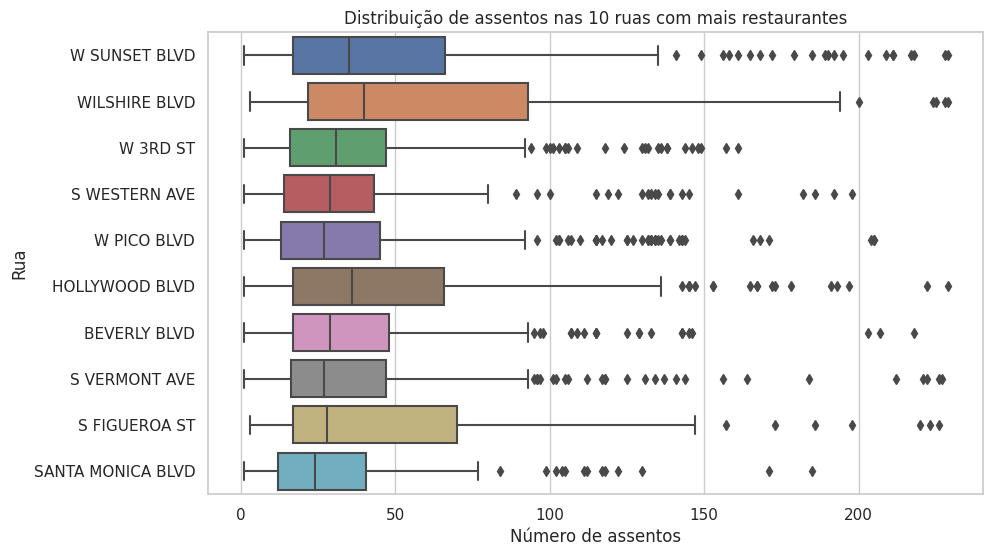

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# garantir top10_streets já criado no 2.7
busy_streets = top10_streets["street"].tolist()

df_busy = df[df["street"].isin(busy_streets)].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_busy, x="number", y="street")
plt.title("Distribuição de assentos nas 10 ruas com mais restaurantes")
plt.xlabel("Número de assentos")
plt.ylabel("Rua")
plt.show()


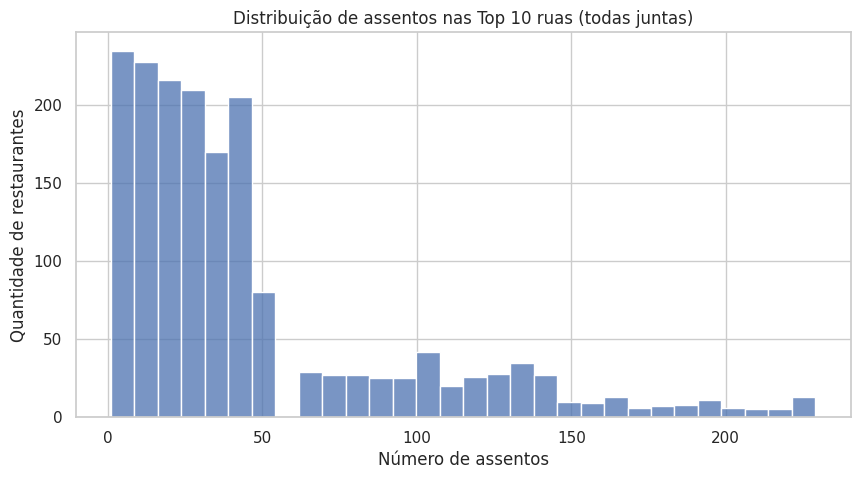

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_busy, x="number", bins=30)
plt.title("Distribuição de assentos nas Top 10 ruas (todas juntas)")
plt.xlabel("Número de assentos")
plt.ylabel("Quantidade de restaurantes")
plt.show()


**Interpretação:**
- Nas ruas com mais restaurantes, a maioria dos estabelecimentos tende a ter **<poucos/moderados/muitos>** assentos.
- Observa-se **<alta/baixa>** variabilidade de assentos entre as ruas: algumas ruas concentram locais **menores**, outras têm mais locais **médios/grandes**.
- A presença de outliers indica que existem alguns estabelecimentos muito grandes, mas eles **não** representam a maioria.


In [14]:
busy_summary = (
    df_busy.groupby("street", as_index=False)
           .agg(median_seats=("number", "median"),
                avg_seats=("number", "mean"),
                n=("number", "size"))
           .sort_values("n", ascending=False)
)

display(busy_summary)


,street,median_seats,avg_seats,n
8,W SUNSET BLVD,35,50.918919,296
7,W PICO BLVD,27,40.878472,288
1,HOLLYWOOD BLVD,36,53.730539,167
9,WILSHIRE BLVD,40,62.130435,161
3,S VERMONT AVE,27,45.878378,148
5,SANTA MONICA BLVD,24,32.390411,146
6,W 3RD ST,31,43.931034,145
0,BEVERLY BLVD,29,44.770370,135
2,S FIGUEROA ST,28,50.761194,134
4,S WESTERN AVE,29,43.101562,128


**Interpretação (2.9):**
- Nas ruas com maior concentração de restaurantes, o tamanho típico dos estabelecimentos é **médio**: as medianas de assentos ficam em torno de **27 a 40** lugares.
- As médias são mais altas (aprox. **33 a 62**), indicando a presença de alguns estabelecimentos grandes, mas como a mediana é menor, esses casos parecem ser **minoria** (outliers).
- Em ruas muito concorridas como **W SUNSET BLVD**, há grande volume de restaurantes e uma combinação de tamanhos, mas o “padrão” continua sendo **tamanho médio**.
- Tendência geral: áreas com muitos restaurantes parecem sustentar melhor operações **padronizadas e de porte médio**, com capacidade suficiente para fluxo constante sem exigir estrutura de “restaurante grande”.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As manipulações solicitadas relativas ao endereço e análises correspondentes foram realizadas! Gráficos e conclusão estão presentes conforme solicitado.
</div>


## Conclusão geral e recomendações

**Resumo do mercado**
- O mercado de LA tem uma mistura de tipos, com presença relevante de redes em formatos como **Bakery, Cafe e Fast Food**.
- Redes não são, em geral, “poucos locais gigantes”: a expansão tende a ocorrer por **replicação de unidades**, e não por aumento de assentos.
- Nas ruas com maior concentração de restaurantes, o tamanho típico dos estabelecimentos é **médio** (mediana ~ **27–40** assentos), com alguns outliers grandes.

**Recomendação para a cafeteria com garçons robôs**
- O formato mais consistente com padronização e escala é **Cafe** (e/ou uma operação híbrida Cafe + Bakery).
- Em termos de capacidade, uma faixa recomendada é **30–40 assentos**, pois:
  - está alinhada ao padrão das ruas mais concorridas (onde há demanda),
  - reduz risco operacional e custo fixo comparado a formatos maiores (ex.: Restaurant/Bar),
  - ainda permite volume suficiente para diluir custo de tecnologia (robôs) e manter fluxo.

**Possibilidade de desenvolver uma rede**
- A presença de redes em **Cafe/Bakery/Fast Food** e o padrão de unidades de porte médio sugerem que existe **potencial real de expansão em rede**.
- Estratégia sugerida: iniciar com **1 unidade piloto** em uma área de alto fluxo e, se os indicadores de demanda e operação forem positivos, replicar o modelo em unidades semelhantes (mesmo layout/processos), mantendo assentos na faixa **30–40** para preservar eficiência e padronização.


Presentation: https://drive.google.com/file/d/178g5S3O7FTTlhF4JQ-k-roGkd8pXLR9w/view?usp=drive_link


<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Solicitei acesso a apresentação.
</div>
